In [1]:
import cv2
import torch
import urllib.request

import matplotlib.pyplot as plt

# url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
# urllib.request.urlretrieve(url, filename)

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [12]:
#model_type = "DPT_Large"     # MiDaS v3 - Large     (highest accuracy, slowest inference speed)
#model_type = "DPT_Hybrid"   # MiDaS v3 - Hybrid    (medium accuracy, medium inference speed)
model_type = "MiDaS_small"  # MiDaS v2.1 - Small   (lowest accuracy, highest inference speed)

midas = torch.hub.load("intel-isl/MiDaS", model_type)

Using cache found in C:\Users\osesn/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\osesn/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


In [13]:
midas.to(device)
midas.eval()

MidasNet_small(
  (pretrained): Module(
    (layer1): Sequential(
      (0): Conv2dSameExport(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
      (3): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (act1): ReLU6(inplace=True)
          (se): Identity()
          (conv_pw): Conv2d(32, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (act2): Identity()
        )
      )
      (4): Sequential(
        (0): InvertedResidual(
          (conv_pw): Conv2d(24, 144, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(144,

In [14]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Using cache found in C:\Users\osesn/.cache\torch\hub\intel-isl_MiDaS_master


In [7]:
filename = "0-023635201142181428210_jpg.rf.81296155e2880a0482f9eb27d8fcd696.jpg"

In [15]:
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

In [16]:
with torch.no_grad():
    prediction = midas(input_batch)

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output = prediction.cpu().numpy()

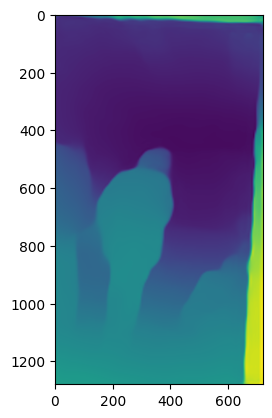

In [17]:
plt.imshow(output)
#plt.show()

In [18]:
import cv2
import torch
import numpy as np
import time

# ============ Config ============
model_type = "MiDaS_small"  # "DPT_Hybrid" | "DPT_Large" | "MiDaS_small"
cam_index = 0
show_width = 960
roi_frac = 0.30
D_REF = 1.00  # metros para calibración
# Umbrales de cercanía (en metros, aplican cuando hay calibración)
NEAR_IN = 0.40   # activar alerta si baja de este valor
NEAR_OUT = 0.45  # desactivar alerta si sube de este valor
# ===============================

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

midas = torch.hub.load("intel-isl/MiDaS", model_type)
midas.to(device)
midas.eval()
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
if model_type in ["DPT_Large", "DPT_Hybrid"]:
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

cap = cv2.VideoCapture(cam_index)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
if not cap.isOpened():
    raise RuntimeError("No se pudo abrir la cámara. Verifica cam_index o permisos.")

def median_depth_in_roi(depth_rel, frac=0.3):
    h, w = depth_rel.shape
    side = int(min(h, w) * frac)
    y1 = h // 2 - side // 2
    x1 = w // 2 - side // 2
    roi = depth_rel[y1:y1+side, x1:x1+side]
    roi = roi[np.isfinite(roi)]
    if roi.size == 0:
        return np.nan, (x1, y1, side, side)
    lo, hi = np.percentile(roi, [5, 95])
    roi = roi[(roi >= lo) & (roi <= hi)]
    if roi.size == 0:
        return np.nan, (x1, y1, side, side)
    return np.median(roi), (x1, y1, side, side)

def colorize_depth(depth_rel):
    d = depth_rel.copy()
    d = d[np.isfinite(d)]
    if d.size == 0:
        return None
    mn, mx = np.percentile(d, [5, 95])
    if mx - mn < 1e-6:
        return None
    norm = (depth_rel - mn) / (mx - mn)
    norm = np.clip(norm, 0, 1)
    norm_u8 = (norm * 255).astype(np.uint8)
    colored = cv2.applyColorMap(norm_u8, cv2.COLORMAP_MAGMA)
    return colored

k_scale = None
calibrated = False
near_state = False  # estado de alerta actual

prev_time = time.time()
fps = 0.0

print("Controles: q=salir, c=calibrar, r=reset, [ / ] D_REF -/+")
try:
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            print("Frame no capturado.")
            break

        h0, w0 = frame_bgr.shape[:2]
        scale = show_width / w0
        show_h = int(h0 * scale)
        frame_bgr_show = cv2.resize(frame_bgr, (show_width, show_h), interpolation=cv2.INTER_LINEAR)

        frame_rgb = cv2.cvtColor(frame_bgr_show, cv2.COLOR_BGR2RGB)
        input_batch = transform(frame_rgb).to(device)

        with torch.no_grad():
            pred = midas(input_batch)
            if pred.dim() == 3:
                pred = pred.unsqueeze(1)
            pred_up = torch.nn.functional.interpolate(
                pred, size=frame_rgb.shape[:2], mode="bicubic", align_corners=False
            ).squeeze(0).squeeze(0)

        depth_rel = pred_up.detach().cpu().numpy()
        z_rel_med, (x1, y1, side, _) = median_depth_in_roi(depth_rel, frac=roi_frac)

        dist_est_m = np.nan
        if calibrated and k_scale is not None and np.isfinite(z_rel_med):
            dist_est_m = float(k_scale * z_rel_med)

        depth_color = colorize_depth(depth_rel)
        depth_vis = depth_color if depth_color is not None else frame_bgr_show.copy()

        now = time.time()
        fps = 0.9 * fps + 0.1 * (1.0 / max(now - prev_time, 1e-6))
        prev_time = now

        # ---- LÓGICA DE ALERTA CON PRINTS ----
        # Solo aplica si hay calibración (tenemos metros)
        if np.isfinite(dist_est_m):
            if not near_state and dist_est_m < NEAR_IN:
                near_state = True
                print(f"[ALERTA] Objeto muy cerca: {dist_est_m:.2f} m (< {NEAR_IN} m)")
            elif near_state and dist_est_m > NEAR_OUT:
                near_state = False
                print(f"[INFO] Distancia segura nuevamente: {dist_est_m:.2f} m (> {NEAR_OUT} m)")
        # -------------------------------------

        # UI
        color_alert = (0, 0, 255) if near_state else (0, 255, 0)
        cv2.rectangle(depth_vis, (x1, y1), (x1+side, y1+side), color_alert, 2)

        y_text = 24
        cv2.putText(depth_vis, f"FPS: {fps:.1f}", (10, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2); y_text += 24
        cv2.putText(depth_vis, f"Model: {model_type}", (10, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1); y_text += 22
        status = "ON" if calibrated else "OFF"
        cv2.putText(depth_vis, f"Calibrated: {status} | D_REF: {D_REF:.2f} m", (10, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1); y_text += 22

        if np.isfinite(dist_est_m):
            cv2.putText(depth_vis, f"Dist(ROI) ~ {dist_est_m:.2f} m", (10, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2); y_text += 26
        else:
            if np.isfinite(z_rel_med):
                cv2.putText(depth_vis, f"Depth_rel(ROI): {z_rel_med:.3f} (sin escala)", (10, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1); y_text += 22
            else:
                cv2.putText(depth_vis, "Depth_rel(ROI): NaN", (10, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1); y_text += 22

        if near_state:
            cv2.putText(depth_vis, "¡¡ALERTA: OBJETO MUY CERCA!!", (10, show_h - 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 3)

        cv2.putText(depth_vis, "q=salir | c=calibrar | r=reset | [ / ] D_REF -/+", (10, show_h - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)

        cv2.imshow("MiDaS depth (estimada)", depth_vis)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('c'):
            if np.isfinite(z_rel_med) and z_rel_med > 0:
                k_scale = D_REF / z_rel_med
                calibrated = True
                near_state = False  # reinicia estado
                print(f"[Calibrado] k_scale = {k_scale:.6f} (D_REF={D_REF:.2f} m, z_rel_med={z_rel_med:.6f})")
            else:
                print("No se pudo calibrar: z_rel_med inválido (mueve la cámara o ajusta ROI).")
        elif key == ord('r'):
            calibrated = False
            k_scale = None
            near_state = False
            print("[Reset] Calibración borrada.")
        elif key == ord('['):
            D_REF = max(0.1, D_REF - 0.1)
            print(f"[Config] D_REF = {D_REF:.2f} m")
        elif key == ord(']'):
            D_REF = D_REF + 0.1
            print(f"[Config] D_REF = {D_REF:.2f} m")

finally:
    cap.release()
    cv2.destroyAllWindows()


Device: cuda


Using cache found in C:\Users\osesn/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\osesn/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\osesn/.cache\torch\hub\intel-isl_MiDaS_master


Controles: q=salir, c=calibrar, r=reset, [ / ] D_REF -/+
